In [1]:
import numpy as np
from scipy import signal as sig
from matplotlib import pyplot as plt

import utilities as utils

# Acquiring radio frequency cavity data

Even though we talk about high-Q superconducting radio frequency cavities as being extremely vulnerable to detuning, in this experiment we take data from a low-Q normal conducting cavity. This is still valid, because a normal conducting pillbox cavity behaves like an L-band resonator, and thus can serve as an easy-to-implement table-top experiment.

### Experimental setup

|          | Frequency | Bandwidth | Quality factor |
|:--------:|:---------:|:---------:|:--------------:|
| Pillbox cavity    | 1.3 GHz    | 708 kHz    |  $1.8 \cdot 10^3$  |

![IMG_0083.jpeg](attachment:ed00d4b9-0dbd-4435-ab94-edff2a6434d1.jpeg "Laboratory setup")
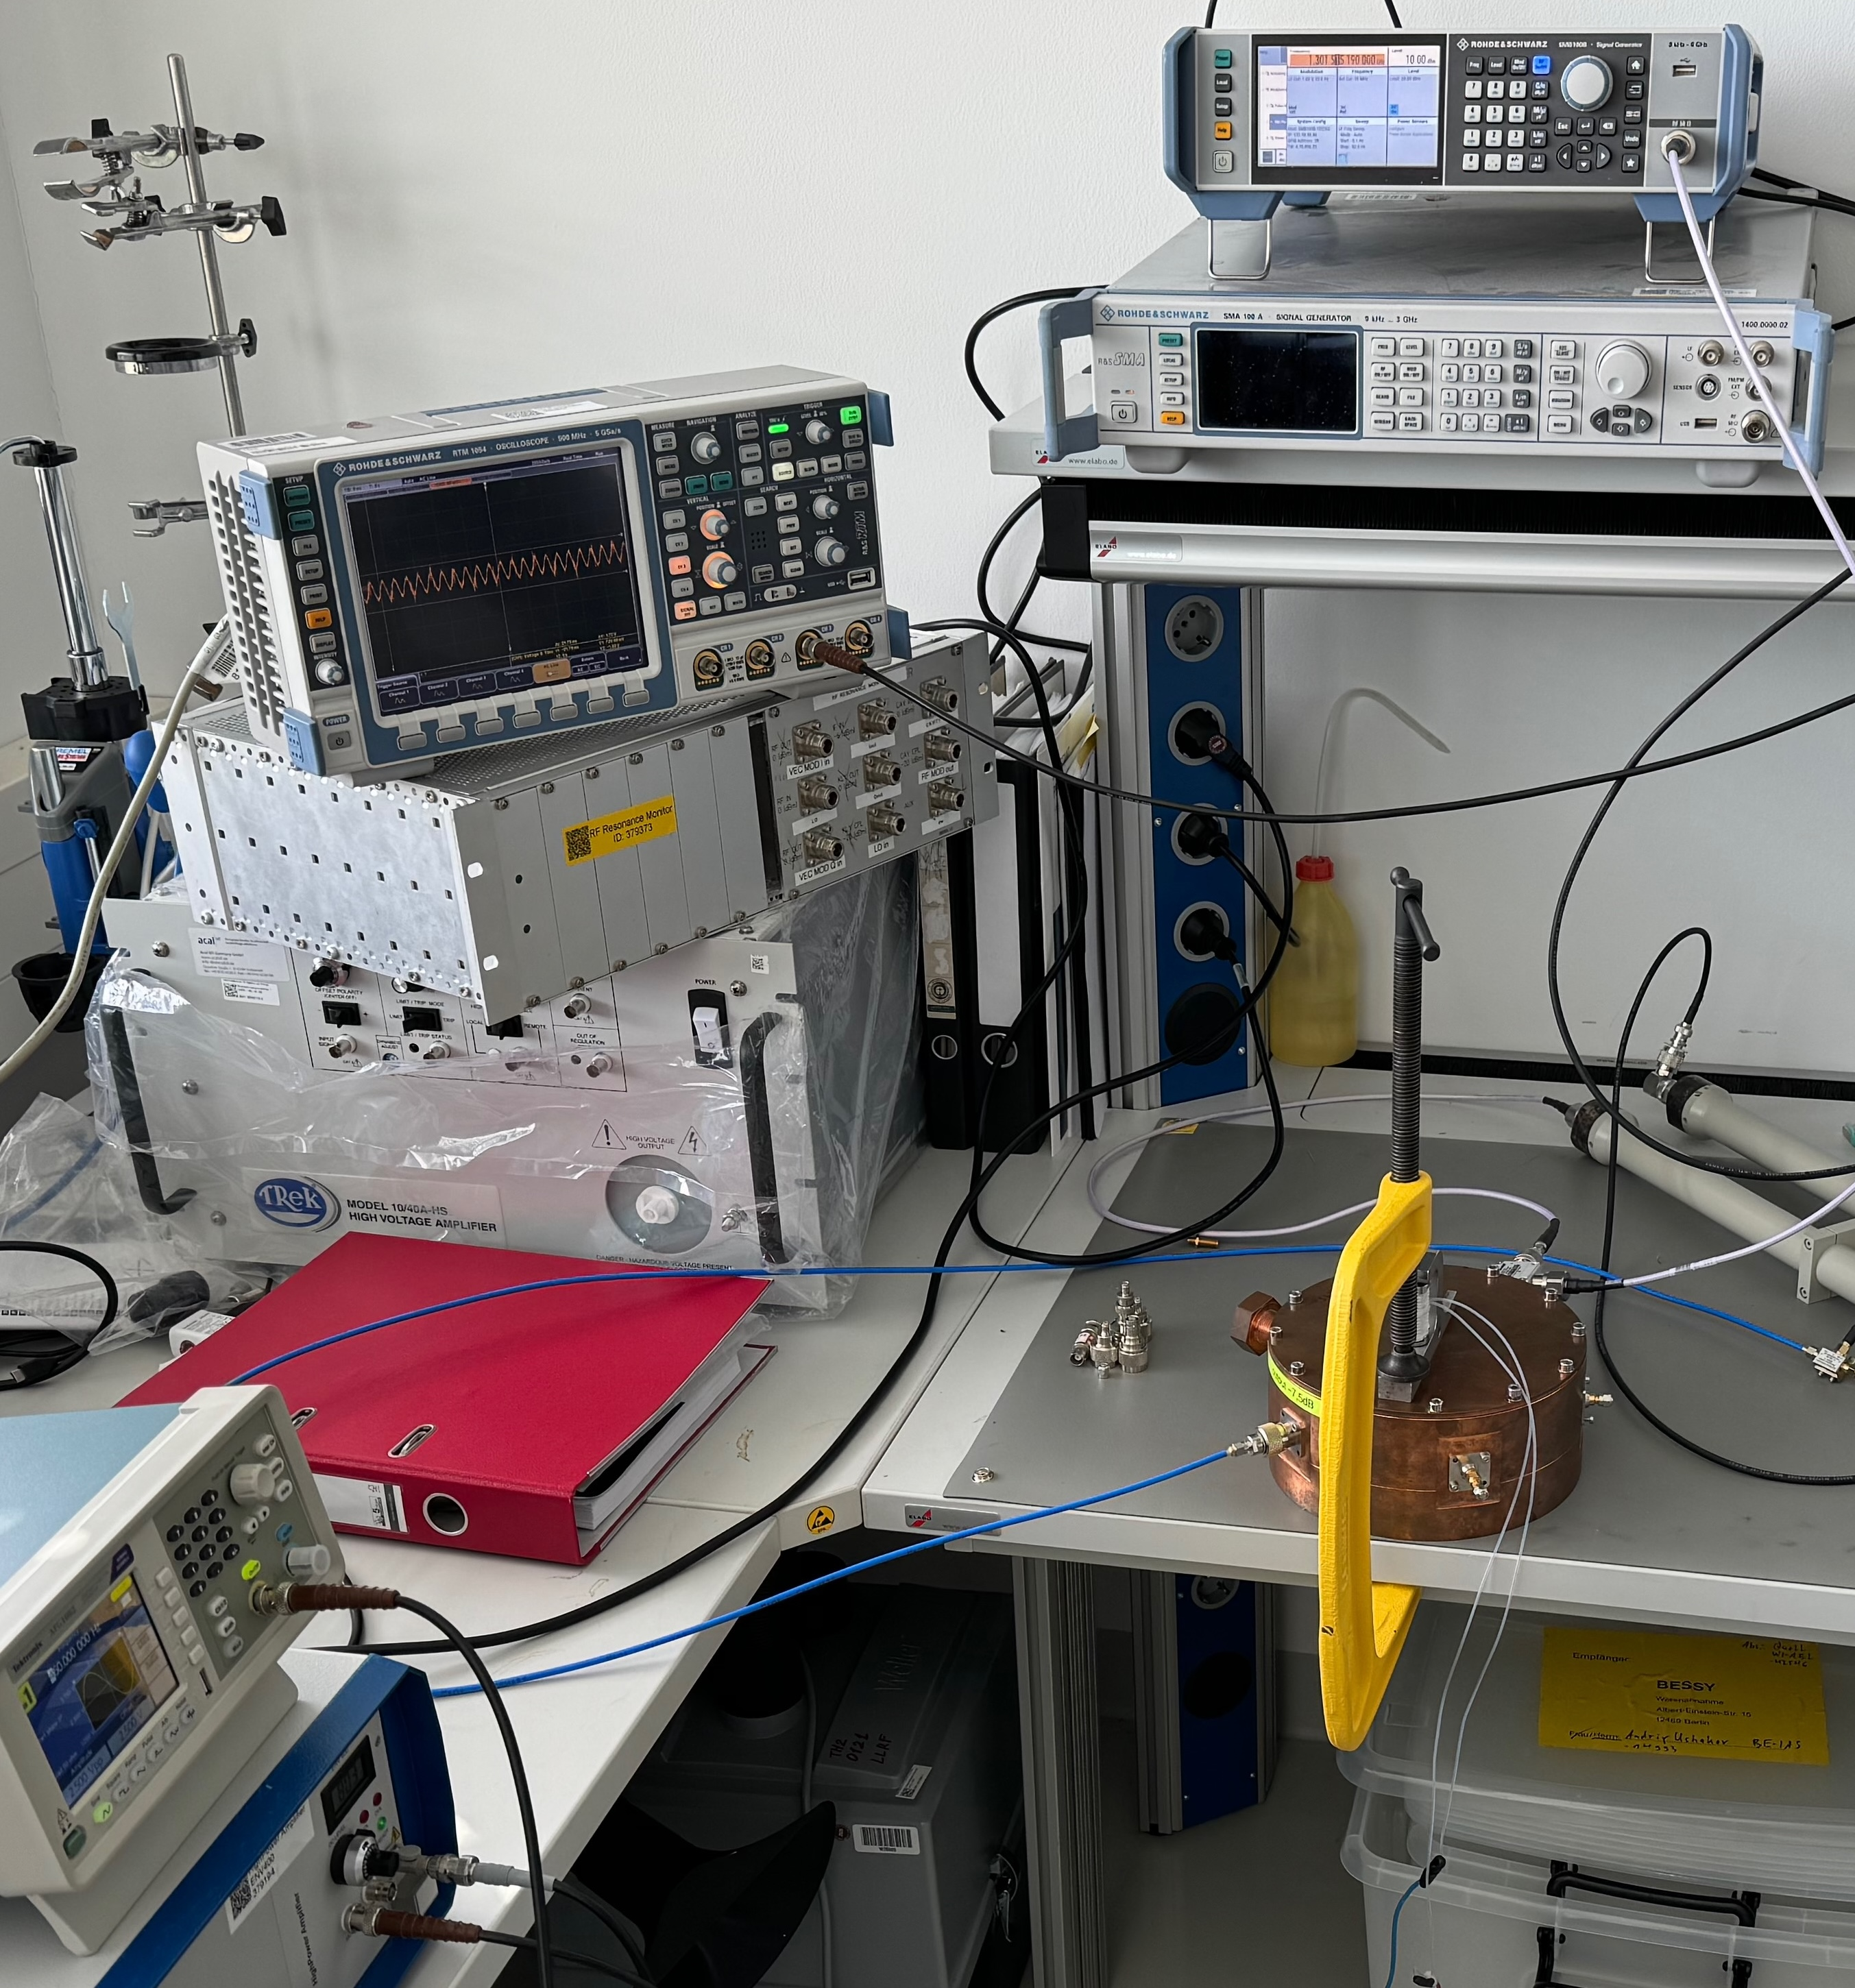

# Conditioning acquired cavity data

We use a 5th-order Butterworth filter to remove high-frequency noise from the cavity data. As a cut-off frequency we specify 2 kHz---this frequency is enough to capture our frequency-of-interest, i.e. 440 Hz. Once the noise is removed, we downsample the data in such a way that every 200 data samples contain a couple of oscillation periods. After empirical testing, we set the downsampling factor to 5. These details are summarized in a Table below.

|                   | Sampling frequency | Time step | Number of samples |
|:------------------|-------------------:|----------:|------------------:|
| Raw data          | 200 kHz            |  5 us     |          10000    |
| Downsampled timeseries        | 40 kHz             |  25 us    |          2000     |

In [2]:
# --! data properties --------------------------------------------------!

raw_fs            = 200_000
cutoff            =   2_000
downsample_factor =       5
timeseries_sz     =     200

In [3]:
# --! helping methods --------------------------------------------------!

def denoise(data, fs, cutoff, filter_ord: int=5):
    """
    Denoises ``data`` by applying a low-pass filter with the specified ``cutoff`` frequency.
    """

    # --! nyquist frequency
    fn = 0.5 * fs

    # --! normalize the cut-off frequency by the nyquist frequency
    cutoff_norm = cutoff / fn

    # --! compute the numerator/denominator (b and a) of a Butterworth filter
    b, a = sig.butter(filter_ord, cutoff_norm, btype='lowpass', analog=False, output='ba')

    # --! return digitally filtered data
    return sig.filtfilt(b, a, data)

def acq_detuning(rawdata_name, fs, cutoff, downsample_factor):
    """
    Acquires detuning timeseries from a raw data file, named ``rawdata_name``. The sampling frequency of the raw data
    is passed as ``fs``. High-frequency noise is removed by low-pass filtering the raw data with the
    specified ``cutoff`` frequency. During data conditioning the data is
    downsampled by a factor ``downsample_factor``.
    """
    rawdata = np.loadtxt('./data/' + rawdata_name + '.csv', delimiter=',', skiprows=1, dtype=np.float32)

    # --! extract voltage from raw data and denoise it
    rawdata_v  = rawdata[:, 1]
    data       = denoise(rawdata_v, fs, cutoff)

    # --! downsample filtered timeseries, such that 200 samples contain a couple of oscillation periods
    return rawdata_v, data, sig.decimate(data, q=downsample_factor, ftype='iir')

def disp_raw(t, rawdata, data):
    plt.figure(figsize=(6, 3))
    plt.title('Raw data filtered')
    plt.plot(t, rawdata, label='raw')
    plt.plot(t, data, label='filtered')
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude [V]')
    plt.legend()
    plt.tight_layout()
    plt.show()

def disp_timeseries(t, timeseries, purpose: str='training'):
    plt.figure(figsize=(6, 3))
    plt.title(f'Timeseries for {purpose}, filtered and downsampled')
    plt.plot(t, timeseries)
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude [V]')
    plt.tight_layout()
    plt.show()


### Stationary data

The stationary data contain a 440 Hz sinusoidal signal with no decay.

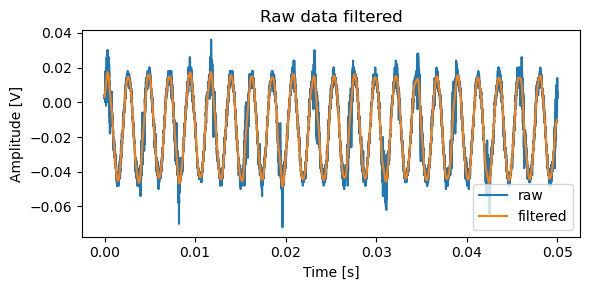

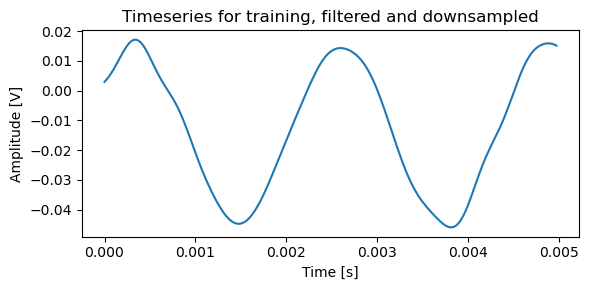

inf >> downsampled data gets a new sampling frequency of 40000.0 Hz
inf >> the new frequency corresponds to a new timestep of 2.5e-05 s
inf >> training files saved


In [4]:
# --! condition and save stationary data -------------------------------------------------!

# --! acquire stationary data
rawdata_name = 'WFM01'
rawdata, data, timeseries = acq_detuning(rawdata_name, raw_fs, cutoff, downsample_factor)

# --! display raw and denoised data
rawdata_sz    = len(rawdata)
raw_ts        = 1/raw_fs
raw_t         = np.arange(0., rawdata_sz*raw_ts, raw_ts)
disp_raw(raw_t, rawdata, data)

# --! display training-ready timeseries (for training, we remove the mean when saving the timeseries to a file)
fs            = raw_fs / downsample_factor
ts            = 1 / fs
t             = np.arange(0., timeseries_sz*ts, ts)
disp_timeseries(t, timeseries[:timeseries_sz])

print(f'inf >> downsampled data gets a new sampling frequency of {fs} Hz')
print(f'inf >> the new frequency corresponds to a new timestep of {ts} s')

# --! save timeseries
savedata_on   = True
savedata_dir  = 'train_meas_g'
savedata_sz   = timeseries_sz
if savedata_on:
    utils.save_timeseries_train([timeseries.reshape(-1, 1)], savedata_dir, savedata_sz)
else:
    print('wrn >> global training file saving is switched off')

### Transition data

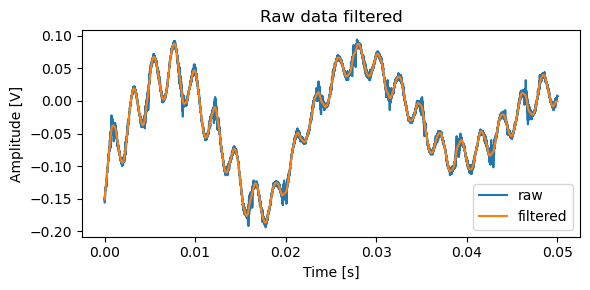

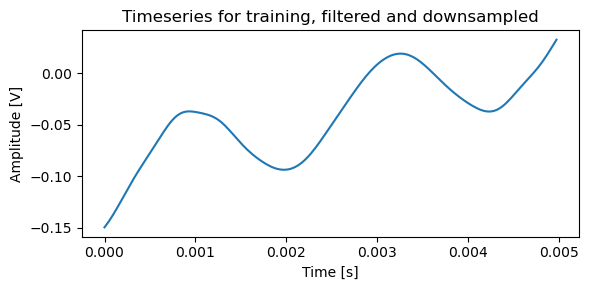

inf >> downsampled data gets a new sampling frequency of 40000.0 Hz
inf >> the new frequency corresponds to a new timestep of 2.5e-05 s
inf >> training files saved


In [5]:
# --! condition and save transition data -------------------------------------------------!

# --! acquire stationary data
rawdata_name      = 'WFM05'
rawdata, data, timeseries = acq_detuning(rawdata_name, raw_fs, cutoff, downsample_factor)

# --! display raw and denoised data
rawdata_sz    = len(rawdata)
raw_ts        = 1/raw_fs
raw_t         = np.arange(0., rawdata_sz*raw_ts, raw_ts)
disp_raw(raw_t, rawdata, data)

# --! display training-ready timeseries (for training, we remove the mean when saving the timeseries to a file)
fs            = raw_fs / downsample_factor
ts            = 1 / fs
t             = np.arange(0., timeseries_sz*ts, ts)
disp_timeseries(t, timeseries[:timeseries_sz])

print(f'inf >> downsampled data gets a new sampling frequency of {fs} Hz')
print(f'inf >> the new frequency corresponds to a new timestep of {ts} s')

# --! save timeseries
savedata_on   = True
savedata_dir  = 'train_meas_l'
savedata_sz   = timeseries_sz
if savedata_on:
    utils.save_timeseries_train([timeseries.reshape(-1, 1)], savedata_dir, savedata_sz)
else:
    print('wrn >> global training file saving is switched off')

### Data for model evaluation

The data for model evaluation feature a slightly different transition than present in the transition data for training. This way, we aim to stress the ability of the model to generalize.

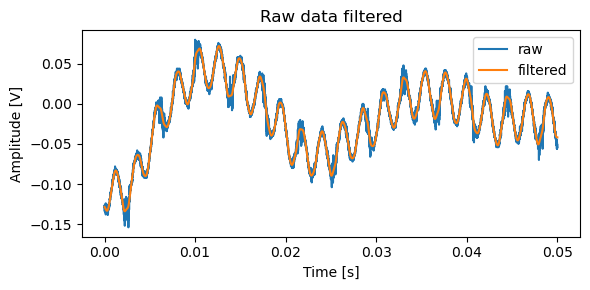

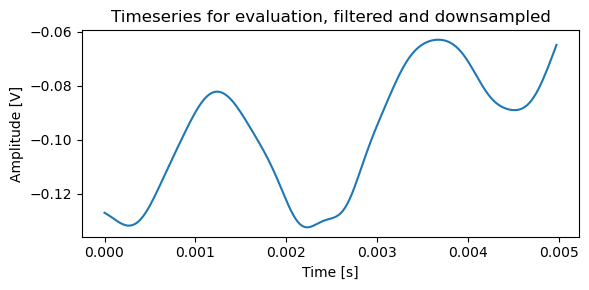

inf >> evaluation file saved


In [6]:
# --! condition and save evaluation data -------------------------------------------------!

# --! acquire stationary data
rawdata_name = 'WFM04'
rawdata, data, timeseries = acq_detuning(rawdata_name, raw_fs, cutoff, downsample_factor)

# --! display raw and denoised data
rawdata_sz    = len(rawdata)
raw_ts        = 1/raw_fs
raw_t         = np.arange(0., rawdata_sz*raw_ts, raw_ts)
disp_raw(raw_t, rawdata, data)

# --! display training-ready timeseries (for training, we remove the mean when saving the timeseries to a file)
fs            = raw_fs / downsample_factor
ts            = 1 / fs
t             = np.arange(0., timeseries_sz*ts, ts)
disp_timeseries(t, timeseries[:timeseries_sz], purpose='evaluation')

# --! save timeseries
savedata_on   = True
savedata_dir  = 'eval_meas'
savedata_sz   = timeseries_sz
if savedata_on:
    utils.save_timeseries_eval([timeseries.reshape(-1, 1)], savedata_dir, savedata_sz)
else:
    print('wrn >> global training file saving is switched off')